# Gradient Field PCA Baseline for DeepFake Detection

This notebook implements a method to distinguish between real and synthetic images using:
1. **Gradient-based PCA** - Analyzes spatial gradient statistics
2. **Spectral Analysis** - Examines frequency domain characteristics

### Mathematical Foundation
- **Luminance Conversion**: BT.709 standard (L = 0.2126R + 0.7152G + 0.0722B)
- **Gradient Analysis**: Sobel operators, eigendecomposition
- **Metrics**: Anisotropy (ρ), Coherence (κ), Energy (E)
- **Spectral**: Power spectrum, spectral slope (β), high-frequency ratio (η)

%pip install matplotlib

In [2]:
# === Setup and Imports ===
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, 
    classification_report, roc_curve
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Find repo root
def find_repo_root(start: Path, max_hops: int = 5) -> Path:
    p = start.resolve()
    markers = ["datasets", ".git", "notebooks"]
    for _ in range(max_hops):
        if any((p / m).exists() for m in markers):
            return p
        p = p.parent
    return start.resolve()

CWD = Path.cwd()
REPO_ROOT = find_repo_root(CWD)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Data paths - try multiple dataset options
DATA_OPTIONS = [
    REPO_ROOT / "datasets" / "OpenFake",
    REPO_ROOT / "datasets" / "DRAGON",
    REPO_ROOT / "data" / "sample",
]

DATA_ROOT = None
for opt in DATA_OPTIONS:
    if opt.exists():
        DATA_ROOT = opt
        break

print(f"CWD:       {CWD}")
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"DATA_ROOT: {DATA_ROOT} | exists: {DATA_ROOT.exists() if DATA_ROOT else False}")

# Seed for reproducibility
np.random.seed(42)

CWD:       /Users/andrewwu/Desktop/DeepFakeDetector/notebooks
REPO_ROOT: /Users/andrewwu/Desktop/DeepFakeDetector
DATA_ROOT: /Users/andrewwu/Desktop/DeepFakeDetector/datasets/OpenFake | exists: True


---
## 1. Luminance Conversion (BT.709)

In [3]:
def rgb_to_luminance(img: np.ndarray) -> np.ndarray:
    """
    Convert RGB image to luminance using BT.709 standard coefficients.
    
    Formula: L = 0.2126 × R + 0.7152 × G + 0.0722 × B
    
    Args:
        img: RGB image array of shape (H, W, 3) with values in [0, 255]
    
    Returns:
        Luminance channel of shape (H, W) with float values
    """
    if img.ndim == 2:
        return img.astype(np.float64)
    
    # BT.709 coefficients
    R_COEFF = 0.2126
    G_COEFF = 0.7152
    B_COEFF = 0.0722
    
    img = img.astype(np.float64)
    luminance = R_COEFF * img[:, :, 0] + G_COEFF * img[:, :, 1] + B_COEFF * img[:, :, 2]
    
    return luminance


def visualize_luminance_conversion(img_path: str):
    """Visualize RGB to Luminance conversion."""
    img = np.array(Image.open(img_path).convert('RGB'))
    luminance = rgb_to_luminance(img)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img)
    axes[0].set_title('Original RGB')
    axes[0].axis('off')
    
    axes[1].imshow(luminance, cmap='gray')
    axes[1].set_title('Luminance (BT.709)')
    axes[1].axis('off')
    
    # Show histogram
    axes[2].hist(luminance.ravel(), bins=256, color='gray', alpha=0.7)
    axes[2].set_title('Luminance Histogram')
    axes[2].set_xlabel('Pixel Value')
    axes[2].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    return luminance

---
## 2. Gradient Field Analysis

In [4]:
def compute_gradients(luminance: np.ndarray) -> tuple:
    """
    Compute spatial gradients using Sobel operators.
    
    G_x = ∂L/∂x (horizontal gradient)
    G_y = ∂L/∂y (vertical gradient)
    
    Args:
        luminance: Grayscale image of shape (H, W)
    
    Returns:
        (G_x, G_y): Gradient components
    """
    # Sobel operators for gradient computation
    G_x = ndimage.sobel(luminance, axis=1, mode='reflect')  # ∂L/∂x
    G_y = ndimage.sobel(luminance, axis=0, mode='reflect')  # ∂L/∂y
    
    return G_x, G_y


def compute_gradient_covariance(G_x: np.ndarray, G_y: np.ndarray) -> np.ndarray:
    """
    Compute the gradient covariance matrix.
    
    M = [(G_x)_1, (G_y)_1; (G_x)_2, (G_y)_2; ...; (G_x)_N, (G_y)_N]
    C = (1/N) × M^T × M
    
    Args:
        G_x: Horizontal gradient of shape (H, W)
        G_y: Vertical gradient of shape (H, W)
    
    Returns:
        C: 2x2 covariance matrix
    """
    # Flatten gradients to form M matrix
    gx_flat = G_x.ravel()
    gy_flat = G_y.ravel()
    
    N = len(gx_flat)
    
    # Compute covariance matrix elements
    C = np.zeros((2, 2))
    C[0, 0] = np.sum(gx_flat * gx_flat) / N  # Var(G_x)
    C[0, 1] = np.sum(gx_flat * gy_flat) / N  # Cov(G_x, G_y)
    C[1, 0] = C[0, 1]                         # Symmetric
    C[1, 1] = np.sum(gy_flat * gy_flat) / N  # Var(G_y)
    
    return C


def compute_gradient_metrics(C: np.ndarray) -> dict:
    """
    Compute gradient-based metrics from eigendecomposition.
    
    Args:
        C: 2x2 covariance matrix
    
    Returns:
        dict with keys: lambda1, lambda2, anisotropy, coherence, energy
    """
    # Eigendecomposition
    eigenvalues, _ = np.linalg.eigh(C)
    eigenvalues = np.sort(eigenvalues)[::-1]  # Sort descending
    
    lambda1 = eigenvalues[0]  # Larger eigenvalue
    lambda2 = max(eigenvalues[1], 1e-10)  # Smaller eigenvalue (avoid division by zero)
    
    # Anisotropy: ρ = λ₁ / λ₂
    # Real images typically have ρ > 1.15 due to coherent physical edges
    anisotropy = lambda1 / lambda2
    
    # Coherence: κ = ((λ₁ - λ₂) / (λ₁ + λ₂))²
    # Higher coherence indicates structured gradient fields
    coherence = ((lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)) ** 2
    
    # Energy: E = λ₁ + λ₂
    # Total gradient magnitude
    energy = lambda1 + lambda2
    
    return {
        'lambda1': lambda1,
        'lambda2': lambda2,
        'anisotropy': anisotropy,
        'coherence': coherence,
        'energy': energy
    }


def visualize_gradient_analysis(img_path: str):
    """Visualize the gradient field analysis pipeline."""
    img = np.array(Image.open(img_path).convert('RGB'))
    luminance = rgb_to_luminance(img)
    G_x, G_y = compute_gradients(luminance)
    C = compute_gradient_covariance(G_x, G_y)
    metrics = compute_gradient_metrics(C)
    
    # Gradient magnitude
    G_mag = np.sqrt(G_x**2 + G_y**2)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(luminance, cmap='gray')
    axes[0, 0].set_title('Luminance')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(G_x, cmap='RdBu', vmin=-np.max(np.abs(G_x)), vmax=np.max(np.abs(G_x)))
    axes[0, 1].set_title('Gradient G_x (∂L/∂x)')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(G_y, cmap='RdBu', vmin=-np.max(np.abs(G_y)), vmax=np.max(np.abs(G_y)))
    axes[0, 2].set_title('Gradient G_y (∂L/∂y)')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(G_mag, cmap='hot')
    axes[1, 0].set_title('Gradient Magnitude')
    axes[1, 0].axis('off')
    
    # Covariance matrix visualization
    axes[1, 1].imshow(C, cmap='coolwarm', interpolation='nearest')
    axes[1, 1].set_title('Covariance Matrix C')
    for i in range(2):
        for j in range(2):
            axes[1, 1].text(j, i, f'{C[i, j]:.2f}', ha='center', va='center', fontsize=12)
    axes[1, 1].set_xticks([0, 1])
    axes[1, 1].set_yticks([0, 1])
    axes[1, 1].set_xticklabels(['G_x', 'G_y'])
    axes[1, 1].set_yticklabels(['G_x', 'G_y'])
    
    # Metrics display
    metrics_text = (
        f"λ₁ = {metrics['lambda1']:.4f}\n"
        f"λ₂ = {metrics['lambda2']:.4f}\n"
        f"Anisotropy (ρ) = {metrics['anisotropy']:.4f}\n"
        f"Coherence (κ) = {metrics['coherence']:.4f}\n"
        f"Energy (E) = {metrics['energy']:.4f}"
    )
    axes[1, 2].text(0.5, 0.5, metrics_text, ha='center', va='center', 
                    fontsize=14, transform=axes[1, 2].transAxes,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].set_title('Gradient Metrics')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return metrics

---
## 3. Frequency Domain Analysis

In [5]:
def compute_power_spectrum(luminance: np.ndarray) -> np.ndarray:
    """
    Compute the 2D power spectrum.
    
    F(u,v) = ∑∑ L(x,y) × exp(-2πi(ux/M + vy/N))
    P(u,v) = |F(u,v)|²
    
    Args:
        luminance: Grayscale image of shape (H, W)
    
    Returns:
        power_spectrum: 2D power spectrum (shifted)
    """
    # 2D FFT
    F = np.fft.fft2(luminance)
    
    # Shift zero frequency to center
    F_shifted = np.fft.fftshift(F)
    
    # Power spectrum
    power_spectrum = np.abs(F_shifted) ** 2
    
    return power_spectrum


def compute_radial_profile(power_spectrum: np.ndarray) -> tuple:
    """
    Compute the radially-averaged power spectrum S(r).
    
    Aggregates power as a function of spatial frequency magnitude r.
    
    Args:
        power_spectrum: 2D power spectrum of shape (H, W)
    
    Returns:
        (radii, radial_profile): Arrays of radii and corresponding average power
    """
    H, W = power_spectrum.shape
    center_y, center_x = H // 2, W // 2
    
    # Create coordinate grids
    y, x = np.ogrid[:H, :W]
    
    # Distance from center
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    r = r.astype(int)
    
    # Maximum radius
    r_max = int(min(center_x, center_y))
    
    # Compute radial profile
    radial_profile = np.zeros(r_max)
    counts = np.zeros(r_max)
    
    for i in range(H):
        for j in range(W):
            radius = r[i, j]
            if radius < r_max:
                radial_profile[radius] += power_spectrum[i, j]
                counts[radius] += 1
    
    # Average (avoid division by zero)
    counts[counts == 0] = 1
    radial_profile = radial_profile / counts
    
    radii = np.arange(r_max)
    
    return radii, radial_profile


def estimate_spectral_slope(radii: np.ndarray, radial_profile: np.ndarray) -> float:
    """
    Estimate spectral slope β via linear regression.
    
    Natural images follow: S(r) ∝ 1/r^β
    Taking logarithms: log(S(r)) = -β × log(r) + c
    
    Natural images typically have β ≈ 2.0 ("1/f² law")
    AI-generated images often have:
        - β < 1.6: Excessive high-frequency noise
        - β > 2.6: Over-smoothed, plastic appearance
    
    Args:
        radii: Array of spatial frequency magnitudes
        radial_profile: Corresponding average power values
    
    Returns:
        beta: Estimated spectral slope
    """
    # Skip DC component (r=0) and very low frequencies
    valid_mask = (radii >= 2) & (radial_profile > 0)
    r_valid = radii[valid_mask]
    P_valid = radial_profile[valid_mask]
    
    if len(r_valid) < 10:
        return np.nan
    
    # Log-log regression
    log_r = np.log(r_valid)
    log_P = np.log(P_valid)
    
    # Linear regression: log(P) = -β × log(r) + c
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_r, log_P)
    
    beta = -slope  # Spectral slope
    
    return beta


def compute_high_frequency_ratio(radii: np.ndarray, radial_profile: np.ndarray, 
                                  cutoff_ratio: float = 0.25) -> float:
    """
    Compute the high-frequency ratio η.
    
    η = (∑_{r>r_c} S(r)) / (∑_{r>0} S(r))
    
    where r_c = min(M,N)/4 (typical cutoff)
    
    Interpretation:
        - η < 0.01: Heavy compression (JPEG artifacts)
        - η > 0.25: Excessive high-frequency noise (diffusion model artifacts)
    
    Args:
        radii: Array of spatial frequency magnitudes
        radial_profile: Corresponding average power values
        cutoff_ratio: Fraction of max radius to use as cutoff (default 0.25)
    
    Returns:
        eta: High-frequency ratio
    """
    r_max = len(radii)
    r_c = int(r_max * cutoff_ratio)  # Cutoff frequency
    
    # Total power (excluding DC)
    total_power = np.sum(radial_profile[1:])
    
    # High-frequency power
    hf_power = np.sum(radial_profile[r_c:])
    
    if total_power == 0:
        return 0.0
    
    eta = hf_power / total_power
    
    return eta


def visualize_spectral_analysis(img_path: str):
    """Visualize the frequency domain analysis pipeline."""
    img = np.array(Image.open(img_path).convert('RGB'))
    luminance = rgb_to_luminance(img)
    power_spectrum = compute_power_spectrum(luminance)
    radii, radial_profile = compute_radial_profile(power_spectrum)
    beta = estimate_spectral_slope(radii, radial_profile)
    eta = compute_high_frequency_ratio(radii, radial_profile)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Luminance
    axes[0, 0].imshow(luminance, cmap='gray')
    axes[0, 0].set_title('Luminance')
    axes[0, 0].axis('off')
    
    # Log power spectrum
    log_ps = np.log1p(power_spectrum)
    axes[0, 1].imshow(log_ps, cmap='hot')
    axes[0, 1].set_title('Log Power Spectrum')
    axes[0, 1].axis('off')
    
    # Radial profile (log-log)
    valid_idx = (radii >= 2) & (radial_profile > 0)
    axes[1, 0].loglog(radii[valid_idx], radial_profile[valid_idx], 'b-', lw=1.5)
    axes[1, 0].set_xlabel('Spatial Frequency (r)')
    axes[1, 0].set_ylabel('Power S(r)')
    axes[1, 0].set_title(f'Radial Power Profile (β = {beta:.3f})')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Linear fit overlay
    if not np.isnan(beta):
        r_fit = radii[valid_idx]
        fit_line = np.exp(-beta * np.log(r_fit) + np.log(radial_profile[valid_idx][0]) + beta * np.log(r_fit[0]))
        axes[1, 0].loglog(r_fit, fit_line, 'r--', lw=2, label=f'Fit: 1/r^{beta:.2f}')
        axes[1, 0].legend()
    
    # Metrics display
    metrics_text = (
        f"Spectral Slope (β) = {beta:.4f}\n\n"
        f"High-Freq Ratio (η) = {eta:.4f}\n\n"
        f"Reference:\n"
        f"  Natural: β ≈ 2.0\n"
        f"  AI (noisy): β < 1.6\n"
        f"  AI (smooth): β > 2.6\n\n"
        f"  η < 0.01: Compressed\n"
        f"  η > 0.25: HF noise"
    )
    axes[1, 1].text(0.5, 0.5, metrics_text, ha='center', va='center', 
                    fontsize=12, transform=axes[1, 1].transAxes,
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    axes[1, 1].set_title('Spectral Metrics')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return {'spectral_slope': beta, 'hf_ratio': eta}

---
## 4. Feature Extraction Pipeline

In [6]:
def extract_features(img_path: str) -> dict:
    """
    Extract all features from a single image.
    
    Features:
        - Gradient: anisotropy, coherence, energy, lambda1, lambda2
        - Spectral: spectral_slope, hf_ratio
    
    Args:
        img_path: Path to the image file
    
    Returns:
        dict with all extracted features
    """
    try:
        # Load and convert to luminance
        img = np.array(Image.open(img_path).convert('RGB'))
        luminance = rgb_to_luminance(img)
        
        # Gradient analysis
        G_x, G_y = compute_gradients(luminance)
        C = compute_gradient_covariance(G_x, G_y)
        gradient_metrics = compute_gradient_metrics(C)
        
        # Spectral analysis
        power_spectrum = compute_power_spectrum(luminance)
        radii, radial_profile = compute_radial_profile(power_spectrum)
        spectral_slope = estimate_spectral_slope(radii, radial_profile)
        hf_ratio = compute_high_frequency_ratio(radii, radial_profile)
        
        # Combine features
        features = {
            'anisotropy': gradient_metrics['anisotropy'],
            'coherence': gradient_metrics['coherence'],
            'energy': gradient_metrics['energy'],
            'lambda1': gradient_metrics['lambda1'],
            'lambda2': gradient_metrics['lambda2'],
            'spectral_slope': spectral_slope,
            'hf_ratio': hf_ratio,
        }
        
        return features
        
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None


def load_dataset(data_root: Path) -> tuple:
    """
    Load dataset from a directory structure:
    data_root/
        real/
        fake/
    OR
    data_root/
        train/
            real/
            fake/
        test/
            real/
            fake/
    
    Returns:
        (image_paths, labels): Lists of paths and binary labels (0=real, 1=fake)
    """
    image_paths = []
    labels = []
    valid_ext = {'.jpg', '.jpeg', '.png', '.webp'}
    
    # Check for train/test structure
    if (data_root / 'train').exists():
        subdirs = [data_root / 'train', data_root / 'test']
    else:
        subdirs = [data_root]
    
    for subdir in subdirs:
        for label, class_name in enumerate(['real', 'fake']):
            class_dir = subdir / class_name
            if not class_dir.exists():
                continue
            for img_file in class_dir.iterdir():
                if img_file.suffix.lower() in valid_ext:
                    image_paths.append(str(img_file))
                    labels.append(label)
    
    return image_paths, labels


def extract_dataset_features(image_paths: list, labels: list) -> tuple:
    """
    Extract features from all images in the dataset.
    
    Returns:
        (X, y, feature_names): Feature matrix, labels, and feature names
    """
    features_list = []
    valid_labels = []
    
    for path, label in tqdm(zip(image_paths, labels), total=len(image_paths), desc="Extracting features"):
        features = extract_features(path)
        if features is not None and not any(np.isnan(v) for v in features.values()):
            features_list.append(features)
            valid_labels.append(label)
    
    if not features_list:
        raise ValueError("No valid features extracted!")
    
    feature_names = list(features_list[0].keys())
    X = np.array([[f[k] for k in feature_names] for f in features_list])
    y = np.array(valid_labels)
    
    return X, y, feature_names

---
## 5. Data Loading and Visualization

In [7]:
# Load dataset
if DATA_ROOT is None:
    raise ValueError("No valid data directory found! Please check DATA_OPTIONS.")

image_paths, labels = load_dataset(DATA_ROOT)
print(f"Total images: {len(image_paths)}")
print(f"Real images: {labels.count(0)}")
print(f"Fake images: {labels.count(1)}")

Total images: 200
Real images: 104
Fake images: 96


REAL IMAGE ANALYSIS

Image: /Users/andrewwu/Desktop/DeepFakeDetector/datasets/OpenFake/train/real/train_0000078.jpg

--- Luminance Conversion ---


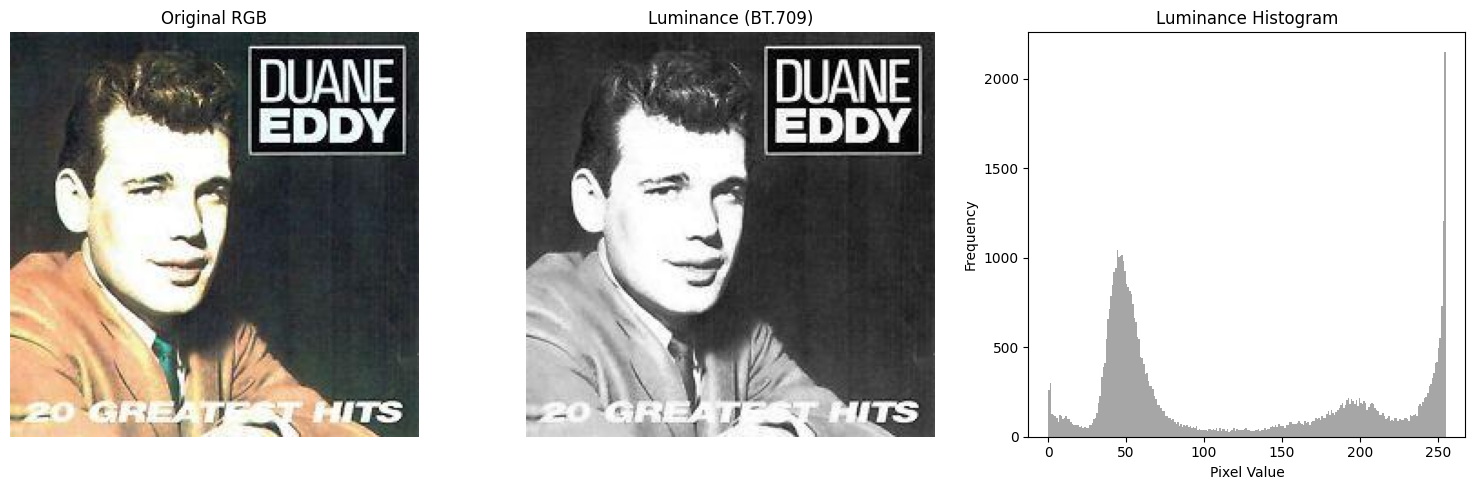


--- Gradient Analysis ---


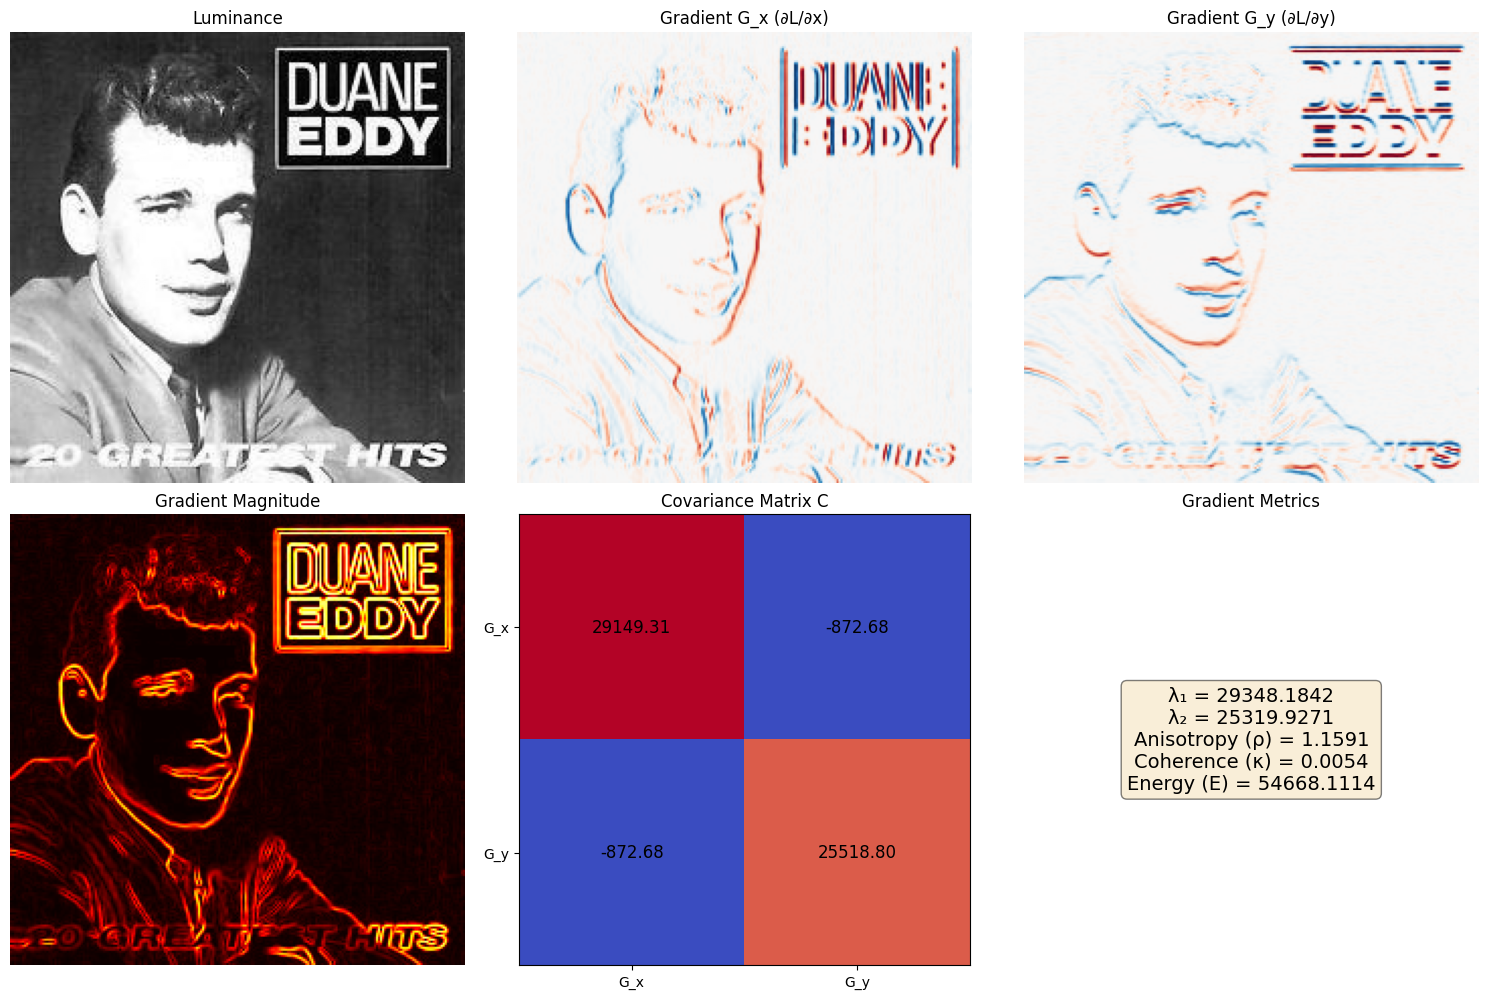


--- Spectral Analysis ---


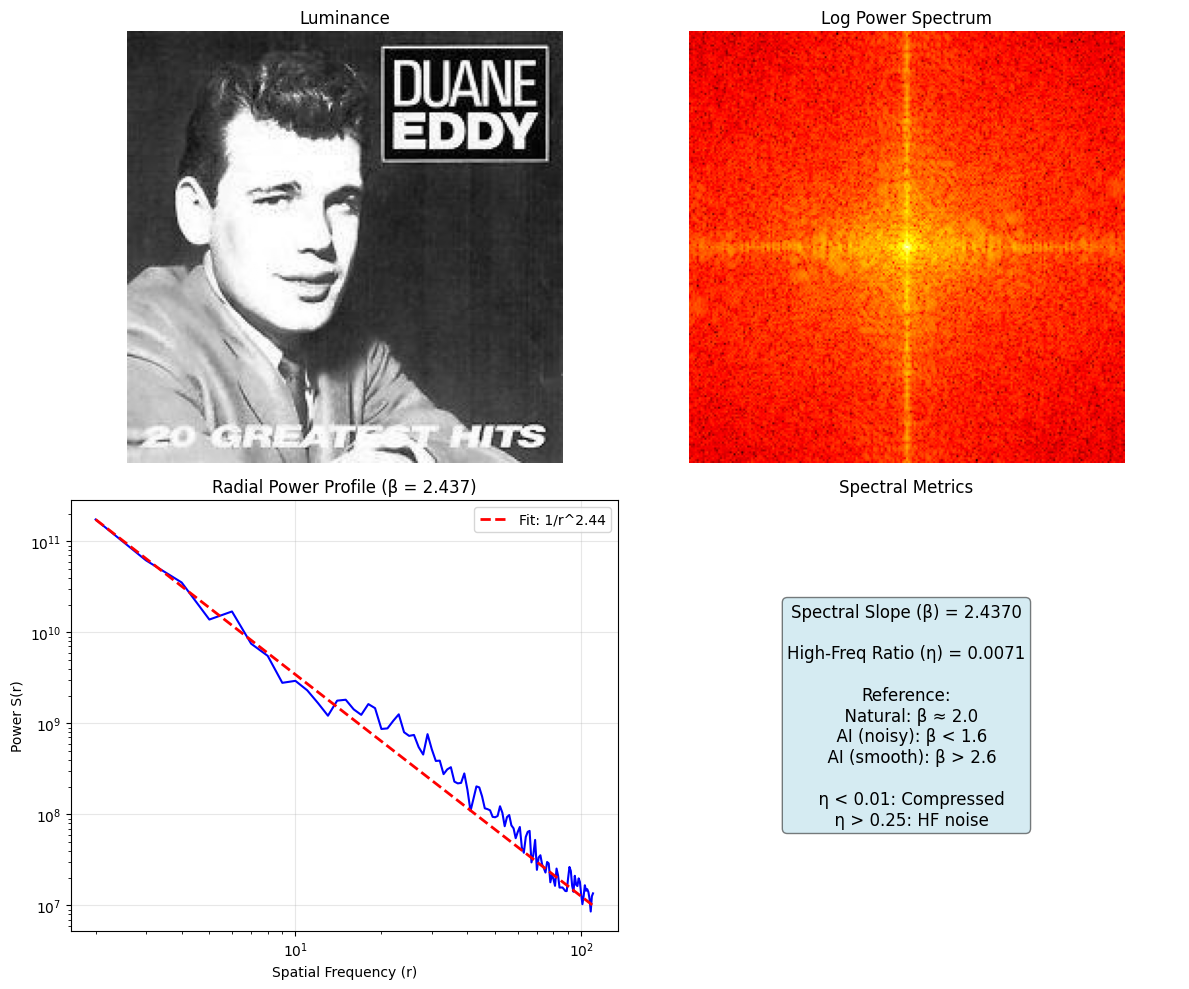

In [8]:
# Visualize pipeline on sample real image
real_paths = [p for p, l in zip(image_paths, labels) if l == 0]
fake_paths = [p for p, l in zip(image_paths, labels) if l == 1]

if real_paths:
    print("=" * 60)
    print("REAL IMAGE ANALYSIS")
    print("=" * 60)
    sample_real = real_paths[0]
    print(f"\nImage: {sample_real}")
    
    print("\n--- Luminance Conversion ---")
    visualize_luminance_conversion(sample_real)
    
    print("\n--- Gradient Analysis ---")
    gradient_metrics = visualize_gradient_analysis(sample_real)
    
    print("\n--- Spectral Analysis ---")
    spectral_metrics = visualize_spectral_analysis(sample_real)

FAKE IMAGE ANALYSIS

Image: /Users/andrewwu/Desktop/DeepFakeDetector/datasets/OpenFake/train/fake/train_0000093.jpg

--- Luminance Conversion ---


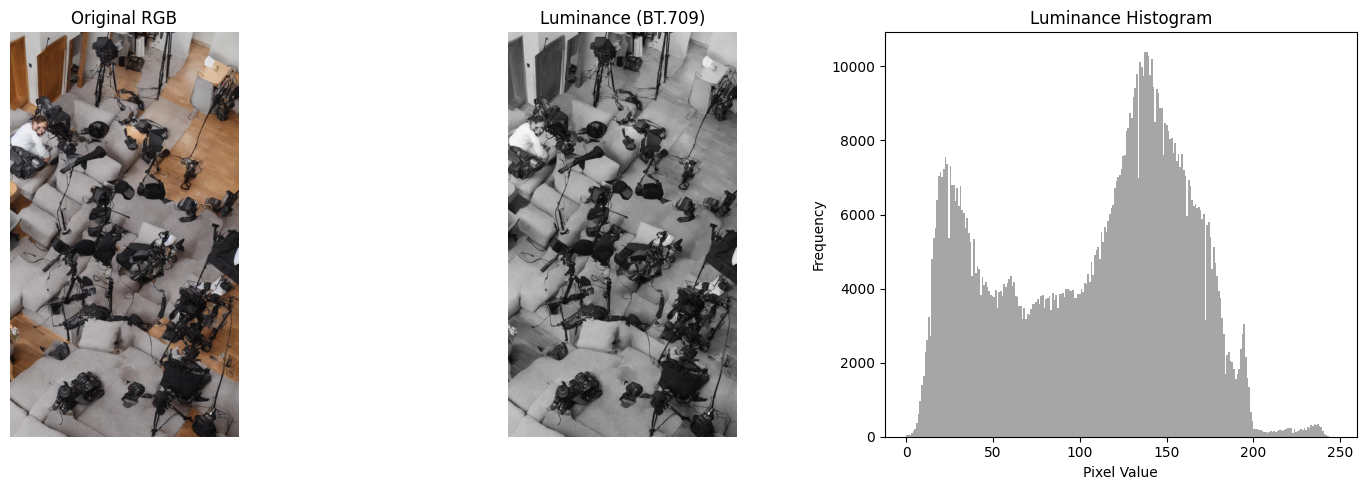


--- Gradient Analysis ---


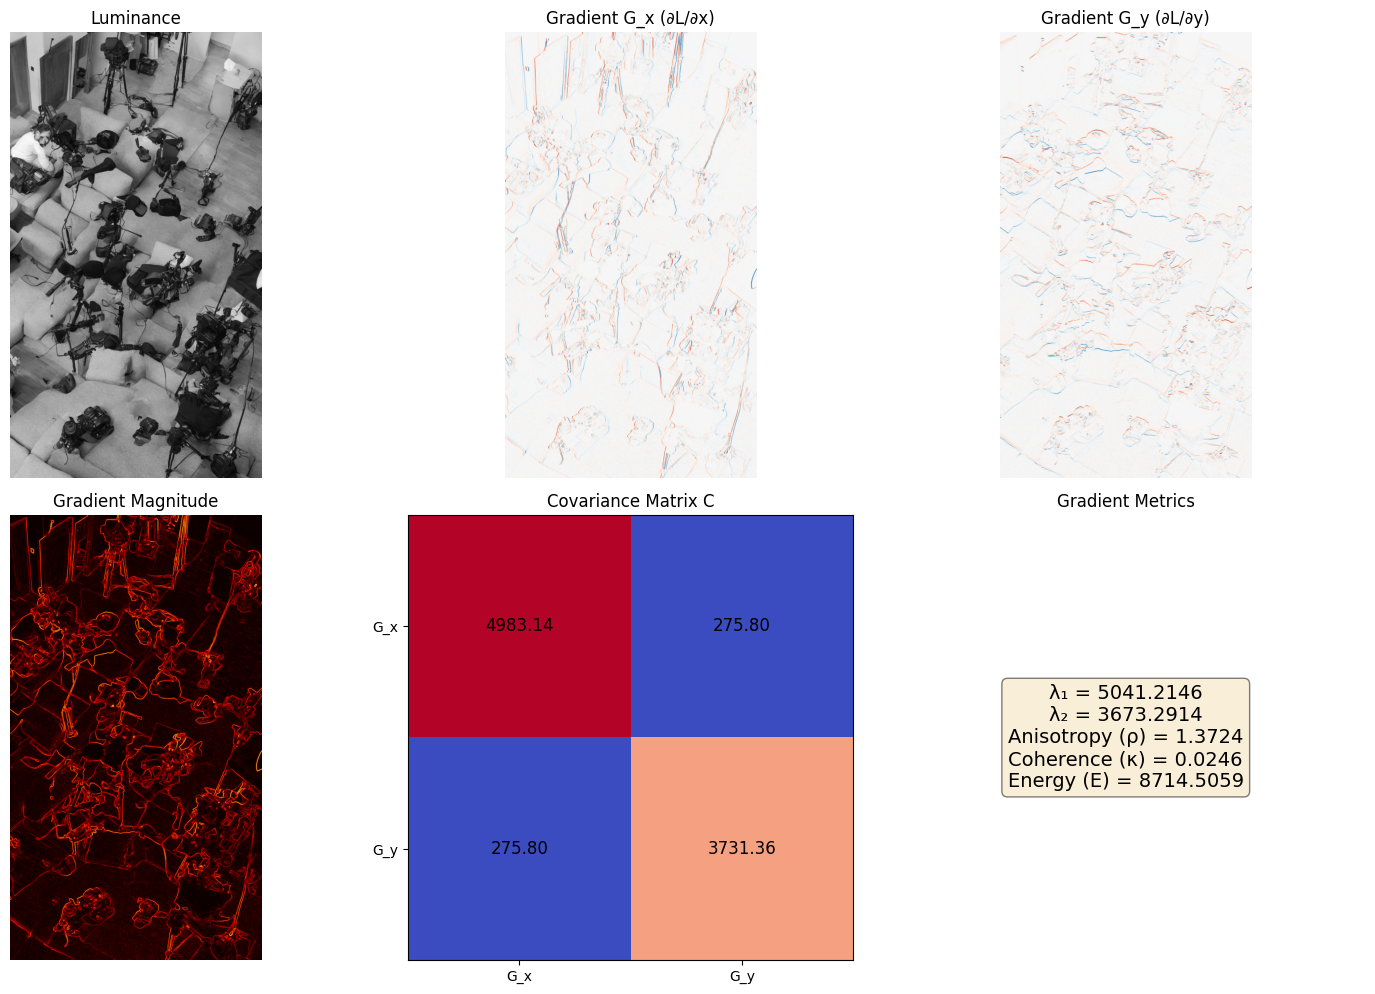


--- Spectral Analysis ---


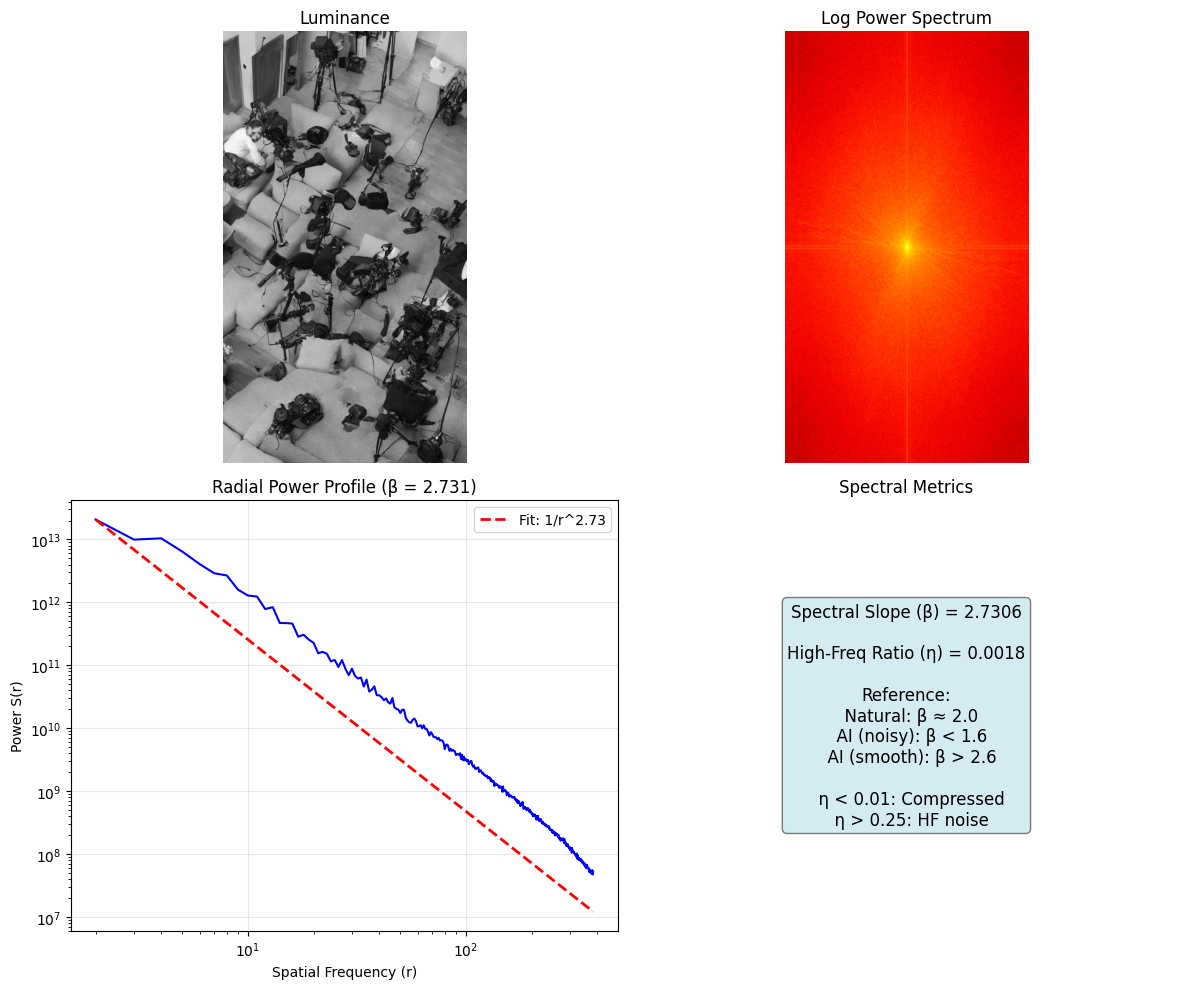

In [9]:
# Visualize pipeline on sample fake image
if fake_paths:
    print("=" * 60)
    print("FAKE IMAGE ANALYSIS")
    print("=" * 60)
    sample_fake = fake_paths[0]
    print(f"\nImage: {sample_fake}")
    
    print("\n--- Luminance Conversion ---")
    visualize_luminance_conversion(sample_fake)
    
    print("\n--- Gradient Analysis ---")
    gradient_metrics = visualize_gradient_analysis(sample_fake)
    
    print("\n--- Spectral Analysis ---")
    spectral_metrics = visualize_spectral_analysis(sample_fake)

---
## 6. Feature Extraction and Classification

In [10]:
# Extract features from all images
X, y, feature_names = extract_dataset_features(image_paths, labels)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Feature names: {feature_names}")
print(f"Class distribution: Real={np.sum(y==0)}, Fake={np.sum(y==1)}")

Extracting features: 100%|██████████| 200/200 [02:14<00:00,  1.49it/s]


Feature matrix shape: (199, 7)
Feature names: ['anisotropy', 'coherence', 'energy', 'lambda1', 'lambda2', 'spectral_slope', 'hf_ratio']
Class distribution: Real=104, Fake=95


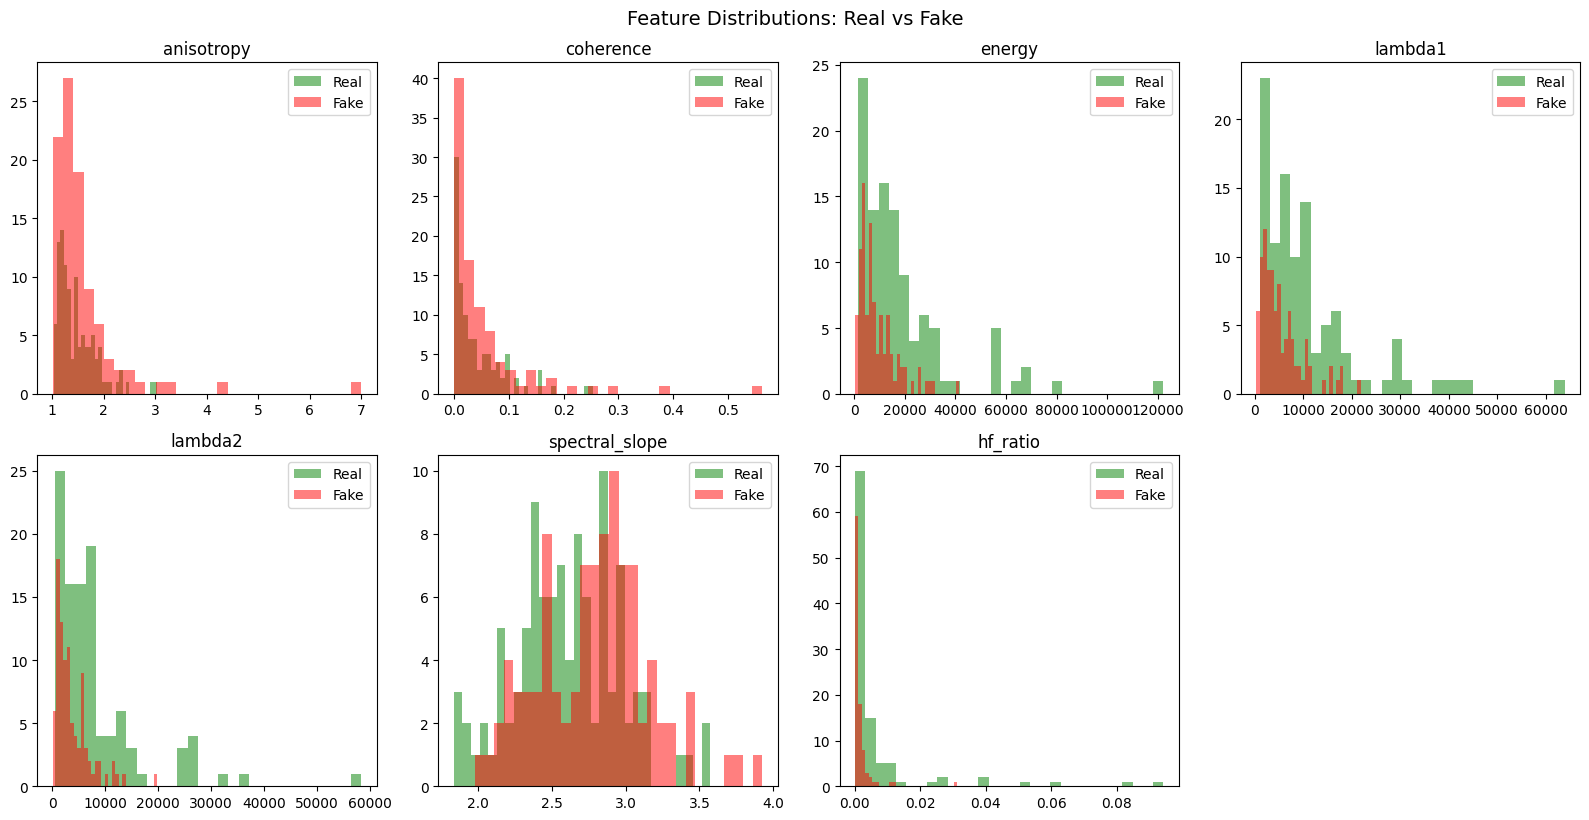

In [11]:
# Visualize feature distributions
n_features = len(feature_names)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, (name, ax) in enumerate(zip(feature_names, axes[:n_features])):
    real_vals = X[y == 0, i]
    fake_vals = X[y == 1, i]
    
    ax.hist(real_vals, bins=30, alpha=0.5, label='Real', color='green')
    ax.hist(fake_vals, bins=30, alpha=0.5, label='Fake', color='red')
    ax.set_title(name)
    ax.legend()

# Hide unused axes
for ax in axes[n_features:]:
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Feature Distributions: Real vs Fake', y=1.02, fontsize=14)
plt.show()

In [12]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: 159 samples
Test set: 40 samples


In [13]:
# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)

# Train Logistic Regression Classifier
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_scaled, y_train)

print("Models trained successfully!")

Models trained successfully!


---
## 7. Evaluation and Metrics

In [14]:
def evaluate_model(clf, X_test, y_test, model_name="Model"):
    """Evaluate classifier and display metrics."""
    # Predictions
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auroc = roc_auc_score(y_test, y_proba)
    
    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUROC:     {auroc:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auroc': auroc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }


# Evaluate both models
rf_results = evaluate_model(rf_clf, X_test_scaled, y_test, "Random Forest")
lr_results = evaluate_model(lr_clf, X_test_scaled, y_test, "Logistic Regression")


Random Forest Results
Accuracy:  0.5500
Precision: 0.5263
Recall:    0.5263
F1-Score:  0.5263
AUROC:     0.6629

Classification Report:
              precision    recall  f1-score   support

        Real       0.57      0.57      0.57        21
        Fake       0.53      0.53      0.53        19

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40


Logistic Regression Results
Accuracy:  0.6250
Precision: 0.6000
Recall:    0.6316
F1-Score:  0.6154
AUROC:     0.7068

Classification Report:
              precision    recall  f1-score   support

        Real       0.65      0.62      0.63        21
        Fake       0.60      0.63      0.62        19

    accuracy                           0.62        40
   macro avg       0.62      0.63      0.62        40
weighted avg       0.63      0.62      0.63        40



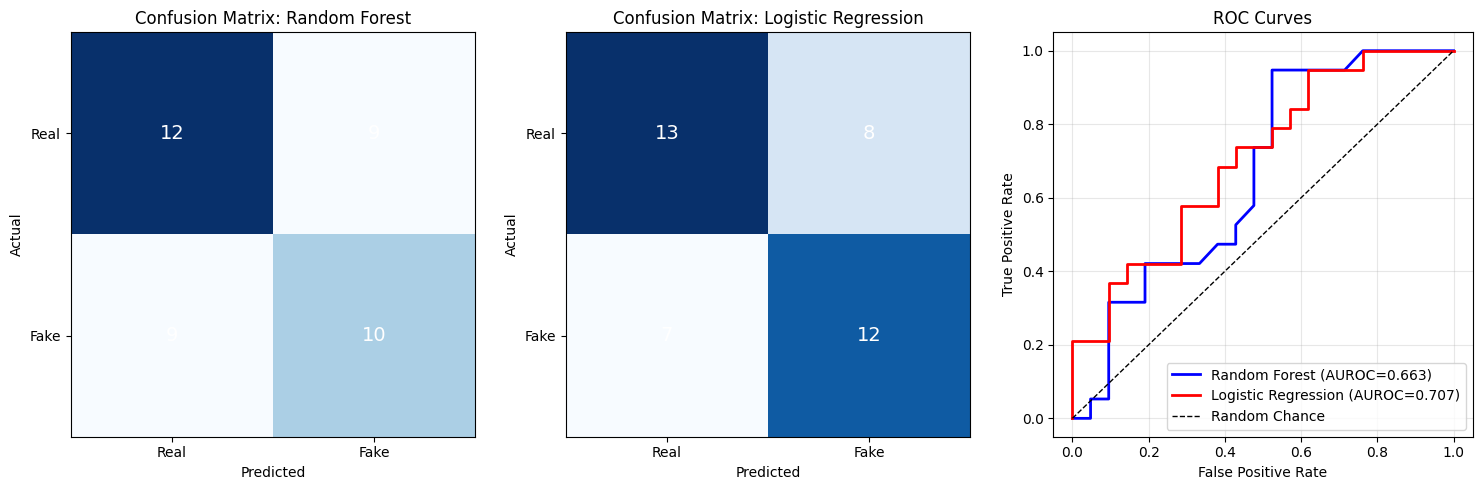

In [15]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_results['y_pred'])
im = axes[0].imshow(cm_rf, cmap='Blues')
axes[0].set_title('Confusion Matrix: Random Forest')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Real', 'Fake'])
axes[0].set_yticklabels(['Real', 'Fake'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_rf[i, j]), ha='center', va='center', fontsize=14, 
                     color='white' if cm_rf[i, j] > cm_rf.max()/2 else 'black')

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, lr_results['y_pred'])
im = axes[1].imshow(cm_lr, cmap='Blues')
axes[1].set_title('Confusion Matrix: Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Real', 'Fake'])
axes[1].set_yticklabels(['Real', 'Fake'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_lr[i, j]), ha='center', va='center', fontsize=14,
                     color='white' if cm_lr[i, j] > cm_lr.max()/2 else 'black')

# ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_results['y_proba'])
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_results['y_proba'])

axes[2].plot(fpr_rf, tpr_rf, 'b-', lw=2, label=f'Random Forest (AUROC={rf_results["auroc"]:.3f})')
axes[2].plot(fpr_lr, tpr_lr, 'r-', lw=2, label=f'Logistic Regression (AUROC={lr_results["auroc"]:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curves')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

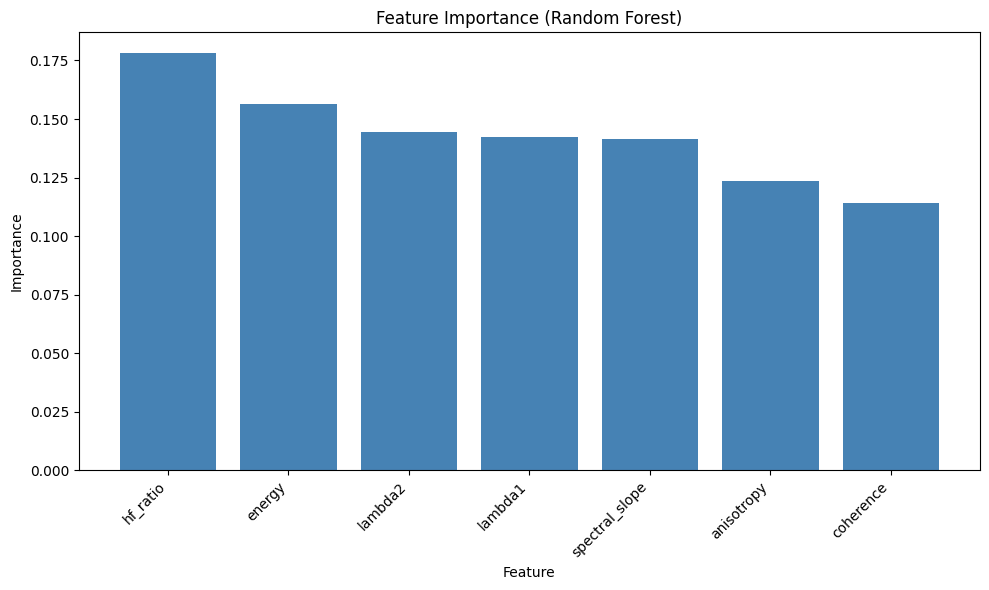


Feature Importance Ranking:
  1. hf_ratio: 0.1781
  2. energy: 0.1563
  3. lambda2: 0.1446
  4. lambda1: 0.1422
  5. spectral_slope: 0.1413
  6. anisotropy: 0.1235
  7. coherence: 0.1140


In [16]:
# Feature importance (Random Forest)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), importances[indices], color='steelblue')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for i, idx in enumerate(indices):
    print(f"  {i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

---
## 8. Summary

In [17]:
# Final summary table
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"\nDataset: {DATA_ROOT}")
print(f"Total samples: {len(y)}")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"\nFeatures used ({len(feature_names)}):")
for name in feature_names:
    print(f"  - {name}")

print(f"\n{'Model':<25} {'Accuracy':<10} {'F1-Score':<10} {'AUROC':<10}")
print("-"*55)
print(f"{'Random Forest':<25} {rf_results['accuracy']:<10.4f} {rf_results['f1']:<10.4f} {rf_results['auroc']:<10.4f}")
print(f"{'Logistic Regression':<25} {lr_results['accuracy']:<10.4f} {lr_results['f1']:<10.4f} {lr_results['auroc']:<10.4f}")
print("="*60)


FINAL RESULTS SUMMARY

Dataset: /Users/andrewwu/Desktop/DeepFakeDetector/datasets/OpenFake
Total samples: 199
Training samples: 159
Test samples: 40

Features used (7):
  - anisotropy
  - coherence
  - energy
  - lambda1
  - lambda2
  - spectral_slope
  - hf_ratio

Model                     Accuracy   F1-Score   AUROC     
-------------------------------------------------------
Random Forest             0.5500     0.5263     0.6629    
Logistic Regression       0.6250     0.6154     0.7068    
